# Sweet Spot Threshold Selection — Cat vs. Dog Image Classification

**Purpose.** This notebook reproduces the Sweet Spot experiment used to choose the final image-cleaning policy before preprocessing and feature extraction.

The experiment audits image quality, tests multiple threshold policies using a fixed proxy-validation protocol, checks stability across random seeds, and exports the final cleaning configuration.

## Final result from the completed experiment

| Item | Final value |
|---|---:|
| Selected preset | `minimal_safety` |
| Final cleaning config | `{"enabled": False, "remove_corrupted": True, "remove_duplicates": True}` |
| Raw images | `10,028` |
| Clean images | `10,028` |
| Removed images | `0` |
| Retention | `100.00%` |
| Class balance shift | `0.00%` |
| Mean F1 across stability seeds | `0.992821` |
| Stability success rate | `1.00` |

## Interpretation

The Sweet Spot experiment did **not** find a soft quality-threshold preset that met the practical improvement criterion. Therefore, the final policy keeps the dataset unchanged after safety checks. In other words, the project does **not** apply extra filtering based on blur, entropy, saturation, image size, or similar soft audit metrics.

The final cleaning policy is intentionally conservative:

```python
{
    "enabled": False,
    "remove_corrupted": True,
    "remove_duplicates": True,
    "duplicate_hamming_threshold": 4,
}
```

## 0. Install dependencies and download project modules from GitHub

This notebook expects the project repository to contain a `modules/` folder.

Set the repository link below before running the notebook. The notebook will clone the repository, copy `modules/` into `/content/modules`, and import the project backend from there.

If your repository structure is different, update `MODULES_SUBDIR`.

In [ ]:
# =========================
# GitHub module setup
# =========================

from pathlib import Path
import shutil
import sys
import os

GITHUB_REPO_URL = "https://github.com/kahn-29/252-MachineLearning-Assignment1.git"
GITHUB_BRANCH = "main"

REPO_DIR = Path("/content/project_repo")

!pip install -q kagglehub imagehash opencv-python-headless

if REPO_DIR.exists():
    shutil.rmtree(REPO_DIR)

!git clone --depth 1 --branch "{GITHUB_BRANCH}" "{GITHUB_REPO_URL}" "{REPO_DIR}"

# Add repo to sys.path so modules can be imported directly
if str(REPO_DIR) not in sys.path:
    sys.path.insert(0, str(REPO_DIR))

print("Cloned repository to:", REPO_DIR)
print("Available module files:")
for path in sorted((REPO_DIR / "modules").glob("*.py")):
    print("-", path.name)


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 296.7/296.7 kB 5.8 MB/s eta 0:00:00
Cloning into '/content/project_repo'...
remote: Enumerating objects: 46, done.
remote: Counting objects: 100% (46/46), done.
remote: Compressing objects: 100% (44/44), done.
remote: Total 46 (delta 0), reused 39 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (46/46), 4.27 MiB | 10.24 MiB/s, done.
Modules copied to: /content/modules
Available module files:
- __init__.py
- artifacts.py
- backbones.py
- classical_models.py
- cleaning.py
- config_utils.py
- data_utils.py
- datasets.py
- deep_learning.py
- evaluation.py
- feature_extraction.py
- grid_search.py
- image_audit.py
- threshold_experiments.py
- transforms.py
- visualization.py


## 1. Import libraries and project modules

The notebook uses the project modules as the backend. The notebook itself remains the front-end for experiment explanation, execution, and visualization.

In [2]:
from pathlib import Path
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from modules.config_utils import (
    get_default_config,
    deep_update,
    validate_config,
    set_seed,
    get_device,
    ensure_dirs,
)

from modules.data_utils import (
    resolve_dataset_root,
    build_raw_dataframe,
    summarize_class_distribution,
)

from modules.image_audit import (
    audit_dataframe,
    describe_audit_metrics,
)

from modules.cleaning import (
    apply_cleaning,
    summarize_cleaning,
    summarize_removal_reasons,
    evaluate_cleaning_retention,
)

from modules.transforms import get_hybrid_transform

from modules.feature_extraction import extract_features

from modules.threshold_experiments import (
    get_default_threshold_specs,
    get_default_cleaning_presets,
    make_proxy_split,
    evaluate_cleaning_mask,
    run_single_metric_threshold_sweep,
    evaluate_cleaning_presets,
    run_cleaning_stability_check,
    select_cleaning_policy,
    build_cleaning_report_payload,
)

from modules.artifacts import (
    save_json,
    save_dataframe,
    save_numpy,
    load_numpy,
)

from modules.visualization import (
    plot_class_distribution_bar,
    plot_class_distribution_pie,
    plot_metric_distribution,
    plot_metric_correlation_heatmap,
    plot_threshold_sweep_results,
    plot_image_grid_from_df,
)

## 2. Experiment configuration

The Sweet Spot notebook uses a config-driven setup.

Important settings:

- Dataset: `tongpython/cat-and-dog`
- Proxy feature extractor: EfficientNet-B0
- Proxy classifier inside threshold experiment: Logistic Regression
- Proxy validation: stratified split with `val_size = 0.20`
- Stability seeds: `[11, 42, 77, 123, 2026]`
- Selection rule:
  - accept a preset only if it meets practical F1 gain, retention, and class-balance criteria;
  - otherwise select the default safety policy.

In [3]:
USER_CONFIG = {
    "paths": {
        "workspace": "/content/cat-dog-image-classifier",
        "data_dir": "/content/cat-dog-image-classifier/data",
        "raw_data_dir": "/content/cat-dog-image-classifier/data/raw",
        "processed_data_dir": "/content/cat-dog-image-classifier/data/processed",
        "features_dir": "/content/cat-dog-image-classifier/features",
        "models_dir": "/content/cat-dog-image-classifier/models",
        "reports_dir": "/content/cat-dog-image-classifier/reports",
        "figures_dir": "/content/cat-dog-image-classifier/reports/figures",
        "results_dir": "/content/cat-dog-image-classifier/reports/results",
    },
    "dataset": {
        "dataset_id": "tongpython/cat-and-dog",
        "local_root": None,
        "drop_unknown": True,
    },
    "preprocessing": {
        "mode": "letterbox",
        "image_size": 224,
        "normalize": "imagenet",
    },
    "feature_extraction": {
        "backbone": "efficientnet_b0",
        "pretrained": True,
        "batch_size": 128,
        "num_workers": 0,
        "data_parallel": False,
        "force_recompute": False,
        "on_error": "raise",
    },
    "sweet_spot": {
        "val_size": 0.20,
        "seeds": [11, 42, 77, 123, 2026],
        "default_policy": "minimal_safety",
        "min_delta_f1": 0.001,
        "min_retention_pct": 85.0,
        "max_imbalance_shift": 0.03,
        "proxy_config": {
            "classifier_C": 0.1,
            "min_train_samples": 100,
            "label_col": "label",
        },
        "score_config": {
            "retention_penalty": 0.10,
            "imbalance_penalty": 0.05,
        },
    },
}

config = deep_update(get_default_config(), USER_CONFIG)

# This notebook evaluates cleaning policies, so we keep config["cleaning"] independent
# from the final selected policy until the last section.
validate_config(config)

set_seed(config["seed"], deterministic=config["runtime"].get("deterministic", False))

workspace = Path(config["paths"]["workspace"])
data_dir = Path(config["paths"]["data_dir"])
processed_dir = Path(config["paths"]["processed_data_dir"])
features_dir = Path(config["paths"]["features_dir"]) / "sweet_spot_proxy"
reports_dir = Path(config["paths"]["results_dir"]) / "sweet_spot"
figures_dir = Path(config["paths"]["figures_dir"]) / "sweet_spot"

ensure_dirs(workspace, data_dir, processed_dir, features_dir, reports_dir, figures_dir)

device = get_device()

print("Device:", device)
print("Workspace:", workspace)
print("Reports:", reports_dir)
print("Figures:", figures_dir)
print("Features:", features_dir)

Device: cuda
Workspace: /content/cat-dog-image-classifier
Reports: /content/cat-dog-image-classifier/reports/results/sweet_spot
Figures: /content/cat-dog-image-classifier/reports/figures/sweet_spot
Features: /content/cat-dog-image-classifier/features/sweet_spot_proxy


## 3. Dataset loading and class distribution

The dataset is downloaded directly from KaggleHub through the public dataset ID. No Google Drive or private cloud mount is required.

Expected dataset size from the completed run:

- Total images: `10,028`
- Cat images: `5,011`
- Dog images: `5,017`

In [4]:
dataset_root = resolve_dataset_root(
    dataset_id=config["dataset"]["dataset_id"],
    local_root=config["dataset"]["local_root"],
    kaggle_input_dir=config["dataset"]["kaggle_input_dir"],
    extensions=config["dataset"]["extensions"],
    allow_download=True,
)

raw_df = build_raw_dataframe(
    root=dataset_root,
    extensions=config["dataset"]["extensions"],
    class_map=config["dataset"]["class_map"],
    drop_unknown=config["dataset"]["drop_unknown"],
)

raw_summary_df = summarize_class_distribution(raw_df, label_col="label_name")

save_dataframe(raw_df, reports_dir / "raw_image_index.csv")
save_dataframe(raw_summary_df, reports_dir / "raw_class_distribution.csv")

print("Dataset root:", dataset_root)
print("Raw dataframe shape:", raw_df.shape)

display(raw_summary_df)
display(raw_df.head())

Using Colab cache for faster access to the 'cat-and-dog' dataset.
Dataset root: /kaggle/input/cat-and-dog
Raw dataframe shape: (10028, 6)


,label_name,count,percentage
0,cat,5011,49.97
1,dog,5017,50.03


,sample_id,path,label,label_name,filename,extension
0,0,/kaggle/input/cat-and-dog/test_set/test_set/ca...,0,cat,cat.4001.jpg,.jpg
1,1,/kaggle/input/cat-and-dog/test_set/test_set/ca...,0,cat,cat.4002.jpg,.jpg
2,2,/kaggle/input/cat-and-dog/test_set/test_set/ca...,0,cat,cat.4003.jpg,.jpg
3,3,/kaggle/input/cat-and-dog/test_set/test_set/ca...,0,cat,cat.4004.jpg,.jpg
4,4,/kaggle/input/cat-and-dog/test_set/test_set/ca...,0,cat,cat.4005.jpg,.jpg


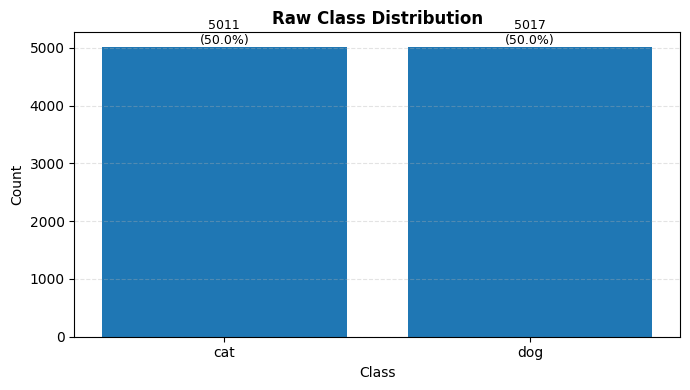

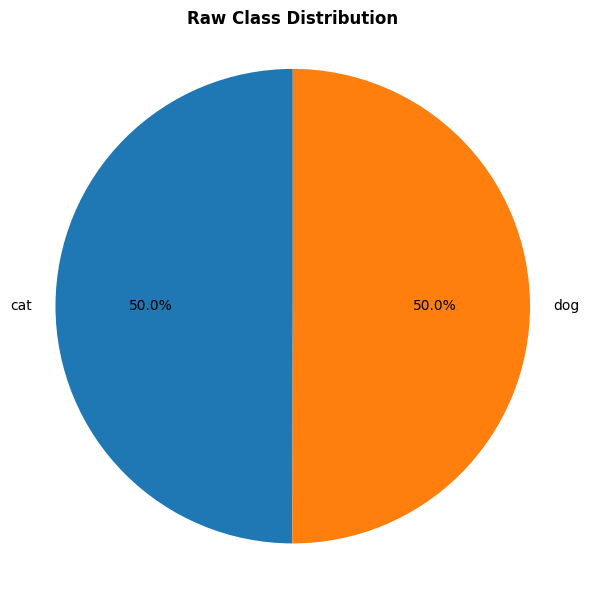

In [5]:
fig, ax = plot_class_distribution_bar(
    raw_df,
    label_col="label_name",
    title="Raw Class Distribution",
    save_path=figures_dir / "raw_class_distribution_bar.png",
    show=True,
)

fig, ax = plot_class_distribution_pie(
    raw_df,
    label_col="label_name",
    title="Raw Class Distribution",
    save_path=figures_dir / "raw_class_distribution_pie.png",
    show=True,
)

## 4. Image audit

This section computes quality-related metrics for each image:

- size and aspect ratio;
- blur via Laplacian variance;
- entropy;
- brightness;
- grayscale / near-monochrome ratios;
- saturation and chromaticity;
- center-saliency proxy;
- compression-artifact proxy;
- perceptual hash for duplicate detection.

The audit dataframe is cached to avoid recomputing all metrics when the notebook is rerun.

In [6]:
audit_path = reports_dir / "audit_dataframe.csv"

if audit_path.exists():
    audit_df = pd.read_csv(audit_path)
else:
    audit_df = audit_dataframe(
        raw_df,
        path_col=config["audit"]["path_col"],
        label_col=config["audit"]["label_col"],
        label_name_col=config["audit"]["label_name_col"],
        compute_hash=config["audit"]["compute_hash"],
        preserve_cols=["sample_id"] if "sample_id" in raw_df.columns else None,
        show_progress=True,
    )
    save_dataframe(audit_df, audit_path)

audit_stats_df = describe_audit_metrics(audit_df)
save_dataframe(audit_stats_df, reports_dir / "audit_metric_summary.csv")

print("Audit dataframe shape:", audit_df.shape)
display(audit_stats_df)

Auditing images:   0%|          | 0/10028 [00:00<?, ?it/s]

Audit dataframe shape: (10028, 31)


,count,mean,std,min,1%,5%,10%,25%,50%,75%,90%,95%,99%,max
blur_laplacian,10028.0,971.337776,1792.087478,6.749261e+00,26.035995,59.547394,93.814255,187.786918,418.211700,987.357434,2236.669172,3706.367605,8959.514138,42627.022600
entropy,10028.0,7.369314,0.400106,1.621980e+00,6.091403,6.707126,6.920718,7.205523,7.447343,7.629322,7.750570,7.802087,7.879005,7.982241
brightness_mean,10028.0,117.371450,27.411632,2.318366e+01,54.696665,72.423072,82.793506,99.317449,117.149483,134.502445,151.481151,162.821512,187.235858,238.124254
brightness_std,10028.0,56.752996,13.507871,1.567177e+01,26.999541,34.794312,39.564142,47.510186,56.341058,65.662144,74.258418,79.959776,89.465830,113.555591
gray_diff_mean,10028.0,29.663283,17.442504,0.000000e+00,5.675096,9.393019,11.893789,17.309167,25.733459,38.000361,52.649345,62.995219,86.885270,193.906845
gray_diff_p95,10028.0,69.403401,35.912405,0.000000e+00,15.000000,24.000000,29.000000,44.000000,63.000000,87.000000,116.000000,137.000000,188.000000,253.000000
near_gray_ratio_10,10028.0,0.299068,0.215406,0.000000e+00,0.001372,0.018559,0.044459,0.122849,0.260523,0.442879,0.608311,0.716136,0.866287,1.000000
dark_ratio,10028.0,0.034029,0.063635,0.000000e+00,0.000000,0.000000,0.000000,0.000413,0.007386,0.038063,0.102495,0.162071,0.312467,0.819071
bright_ratio,10028.0,0.033150,0.069405,0.000000e+00,0.000000,0.000000,0.000000,0.000180,0.006290,0.034102,0.094687,0.159454,0.338857,0.905371
near_mono_ratio,10028.0,0.067179,0.090793,0.000000e+00,0.000000,0.000203,0.001050,0.008053,0.034163,0.090134,0.177429,0.245745,0.426192,0.952878


## 5. Audit metric visualization

The metric distributions help identify whether aggressive quality thresholds are necessary.

These plots are diagnostic only. The final decision is based on proxy validation and stability checks, not visual inspection alone.

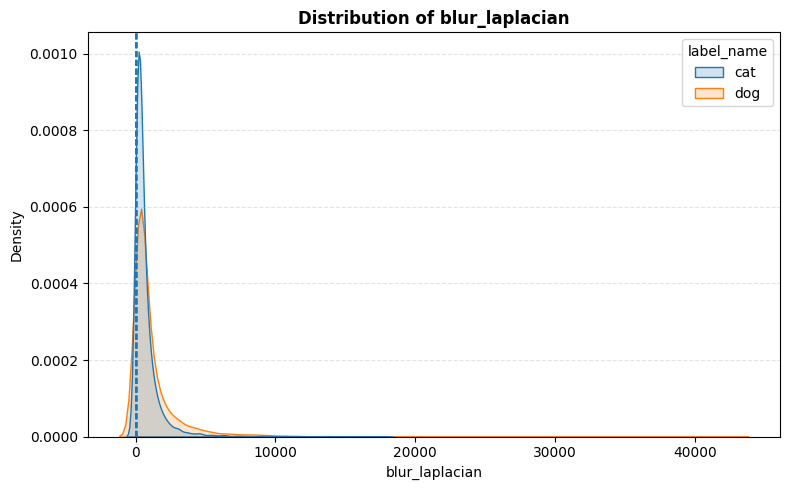

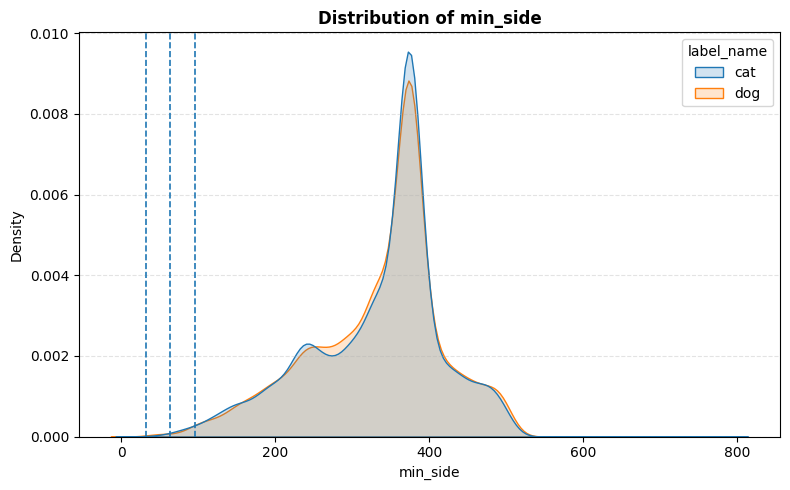

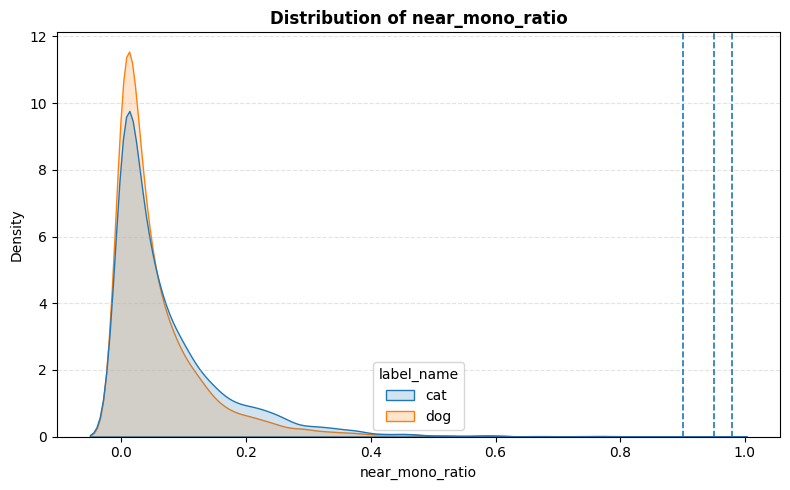

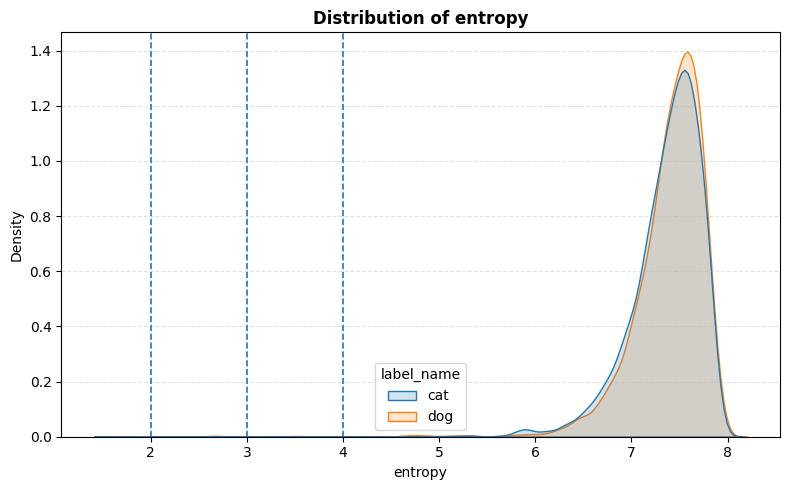

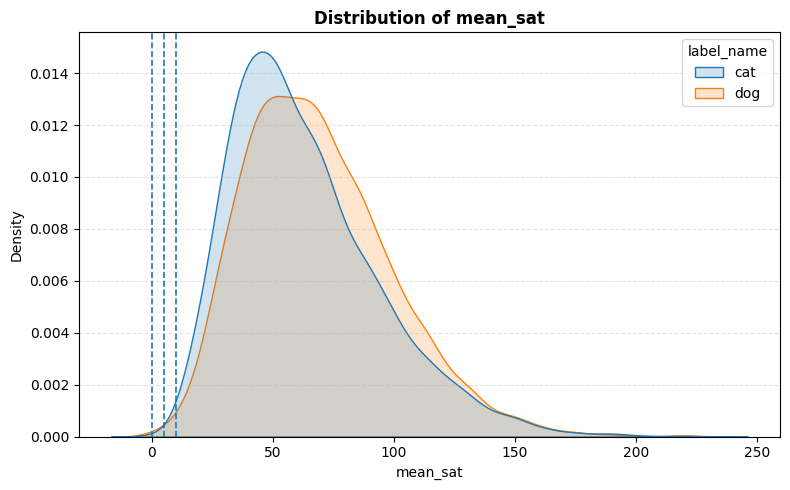

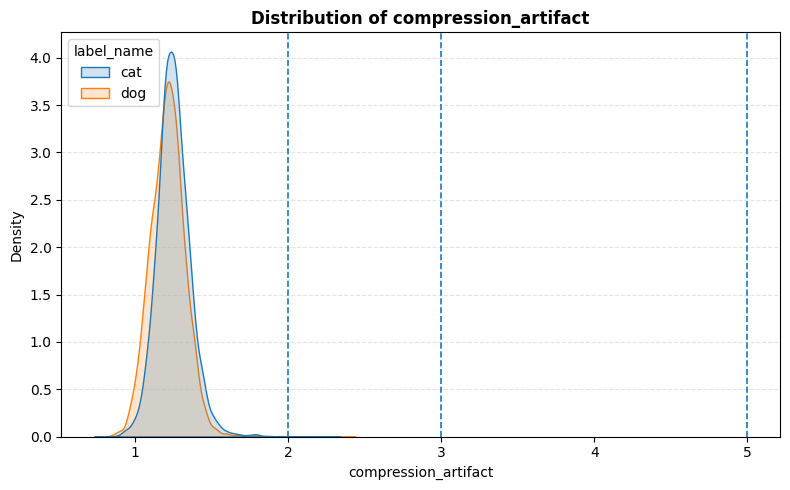

In [7]:
metrics_to_plot = [
    ("blur_laplacian", [20, 50, 75]),
    ("min_side", [32, 64, 96]),
    ("near_mono_ratio", [0.90, 0.95, 0.98]),
    ("entropy", [2.0, 3.0, 4.0]),
    ("mean_sat", [0, 5, 10]),
    ("compression_artifact", [2.0, 3.0, 5.0]),
]

for metric, thresholds in metrics_to_plot:
    if metric in audit_df.columns:
        plot_metric_distribution(
            audit_df,
            metric=metric,
            label_col="label_name",
            thresholds=thresholds,
            save_path=figures_dir / f"metric_distribution_{metric}.png",
            show=True,
        )

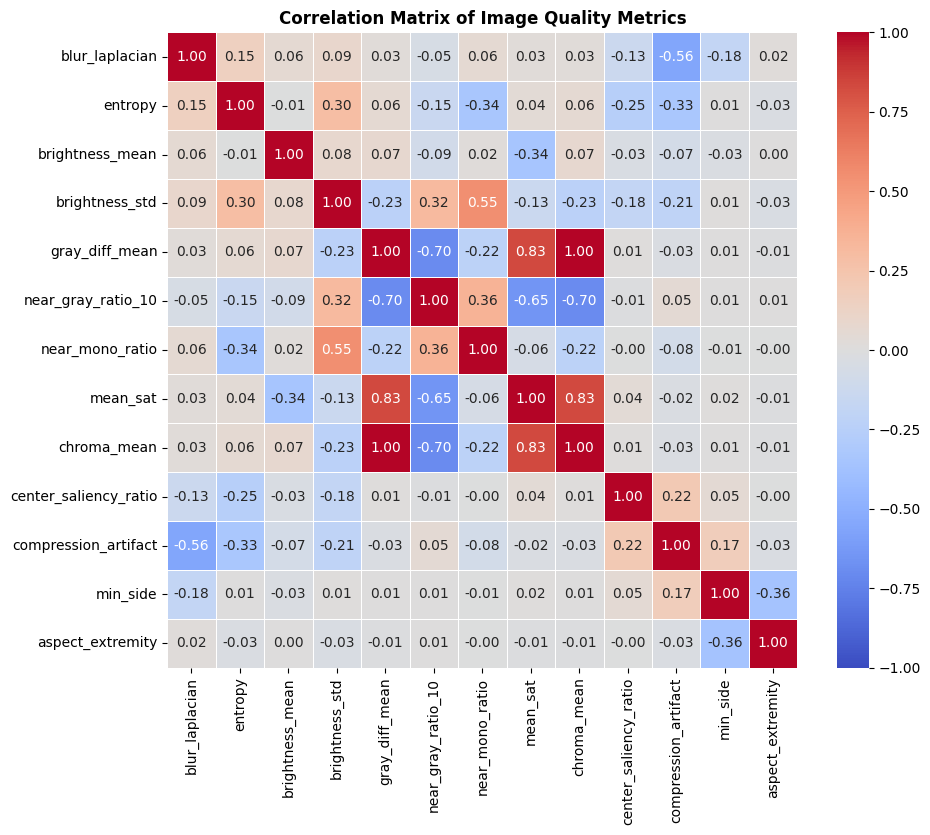

(<Figure size 975x845 with 2 Axes>,
 <Axes: title={'center': 'Correlation Matrix of Image Quality Metrics'}>)

In [8]:
corr_metrics = [
    "blur_laplacian",
    "entropy",
    "brightness_mean",
    "brightness_std",
    "gray_diff_mean",
    "near_gray_ratio_10",
    "near_mono_ratio",
    "mean_sat",
    "chroma_mean",
    "center_saliency_ratio",
    "compression_artifact",
    "min_side",
    "aspect_extremity",
]

plot_metric_correlation_heatmap(
    audit_df,
    metrics=corr_metrics,
    save_path=figures_dir / "audit_metric_correlation_heatmap.png",
    show=True,
)

## 6. Proxy feature extraction

To compare cleaning policies fairly, the notebook uses a fixed proxy model:

1. Extract frozen CNN embeddings using EfficientNet-B0.
2. Train a simple Logistic Regression classifier on filtered training subsets.
3. Evaluate all candidate cleaning policies on the same validation subset.

The proxy features are cached as `.npy` files.

In [9]:
valid_audit_df = audit_df[~audit_df["is_corrupted"].fillna(False).astype(bool)].copy().reset_index(drop=True)

proxy_feature_path = features_dir / "X_proxy.npy"
proxy_label_path = features_dir / "y_proxy.npy"
proxy_audit_path = reports_dir / "proxy_audit_dataframe.csv"

if proxy_feature_path.exists() and proxy_label_path.exists() and proxy_audit_path.exists():
    proxy_audit_df = pd.read_csv(proxy_audit_path)
    X_proxy = load_numpy(proxy_feature_path)
    y_proxy = load_numpy(proxy_label_path)
else:
    proxy_audit_df = valid_audit_df.copy().reset_index(drop=True)

    proxy_transform = get_hybrid_transform(
        mode=config["preprocessing"]["mode"],
        image_size=config["preprocessing"]["image_size"],
        train=False,
        normalize=config["preprocessing"].get("normalize", "imagenet"),
    )

    X_proxy, y_proxy = extract_features(
        df=proxy_audit_df,
        transform=proxy_transform,
        backbone_name=config["feature_extraction"]["backbone"],
        batch_size=config["feature_extraction"]["batch_size"],
        device=device,
        num_workers=config["feature_extraction"]["num_workers"],
        path_col="path",
        label_col="label",
        pretrained=config["feature_extraction"]["pretrained"],
        data_parallel=config["feature_extraction"]["data_parallel"],
        show_progress=True,
        on_error=config["feature_extraction"].get("on_error", "raise"),
    )

    save_dataframe(proxy_audit_df, proxy_audit_path)
    save_numpy(X_proxy, proxy_feature_path)
    save_numpy(y_proxy, proxy_label_path)

print("Proxy feature matrix:", X_proxy.shape)
print("Proxy label vector:", y_proxy.shape)
print("Proxy audit dataframe:", proxy_audit_df.shape)

Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:00<00:00, 140MB/s] 


Extracting features (efficientnet_b0):   0%|          | 0/79 [00:00<?, ?it/s]

Proxy feature matrix: (10028, 1280)
Proxy label vector: (10028,)
Proxy audit dataframe: (10028, 31)


## 7. Baseline proxy result

The baseline keeps all valid images. This is the reference point for threshold filtering.

Expected baseline result from the completed run at seed 42:

| Metric | Value |
|---|---:|
| Accuracy | `0.993519` |
| F1 macro | `0.993519` |
| Training retention | `100.00%` |
| Imbalance shift | `0.000000` |

In [10]:
sweet_cfg = config["sweet_spot"]
proxy_config = sweet_cfg["proxy_config"]
score_config = sweet_cfg["score_config"]

valid_mask = pd.Series(True, index=proxy_audit_df.index, dtype=bool)

train_indices, val_indices = make_proxy_split(
    audit_df=proxy_audit_df,
    valid_mask=valid_mask,
    val_size=sweet_cfg["val_size"],
    seed=config["seed"],
    label_col=proxy_config["label_col"],
)

baseline_result = evaluate_cleaning_mask(
    mask=valid_mask,
    X_all=X_proxy,
    y_all=y_proxy,
    audit_df=proxy_audit_df,
    train_indices=train_indices,
    val_indices=val_indices,
    mask_name="baseline_valid_only",
    threshold="none",
    seed=config["seed"],
    classifier_C=proxy_config["classifier_C"],
    retention_penalty=score_config["retention_penalty"],
    imbalance_penalty=score_config["imbalance_penalty"],
    min_train_samples=proxy_config["min_train_samples"],
)

baseline_df = pd.DataFrame([baseline_result])
save_dataframe(baseline_df, reports_dir / "baseline_proxy_result.csv")

display(baseline_df)

,filter,threshold,seed,status,invalid_reason,accuracy,f1_macro,precision_macro,recall_macro,n_train,n_val,train_retention_pct,positive_ratio_after,imbalance_shift,score
0,baseline_valid_only,none,42,ok,,0.993519,0.993519,0.993529,0.993522,8022,2006,100.0,0.500249,0.0,0.993519


## 8. Single-metric threshold sweep

This section tests individual quality thresholds one at a time, for example:

- blur threshold;
- minimum image side;
- entropy;
- saturation;
- near-monochrome ratio;
- compression-artifact score.

The goal is to see whether any single metric has a useful Sweet Spot: high F1, high retention, and low class-balance shift.

In [11]:
threshold_specs = get_default_threshold_specs()

threshold_sweep_df = run_single_metric_threshold_sweep(
    X=X_proxy,
    y=y_proxy,
    audit_df=proxy_audit_df,
    threshold_specs=threshold_specs,
    train_indices=train_indices,
    val_indices=val_indices,
    base_mask=valid_mask,
    proxy_config=proxy_config,
    score_config=score_config,
    seed=config["seed"],
)

threshold_sweep_df = threshold_sweep_df.sort_values(
    ["filter", "score"],
    ascending=[True, False],
).reset_index(drop=True)

save_dataframe(threshold_sweep_df, reports_dir / "single_metric_threshold_sweep.csv")

display(threshold_sweep_df.head(30))

,filter,threshold,seed,status,invalid_reason,accuracy,f1_macro,precision_macro,recall_macro,n_train,n_val,train_retention_pct,positive_ratio_after,imbalance_shift,score
0,blur_laplacian,20.00,42,ok,,0.994018,0.994018,0.994024,0.994020,7979,2006,99.4640,0.501692,0.001443,0.993410
1,blur_laplacian,30.00,42,ok,,0.994018,0.994018,0.994033,0.994021,7914,2006,98.6537,0.503664,0.003415,0.992501
2,blur_laplacian,50.00,42,ok,,0.992522,0.992522,0.992532,0.992525,7724,2006,96.2852,0.508933,0.008684,0.988373
3,blur_laplacian,75.00,42,ok,,0.993519,0.993519,0.993522,0.993521,7473,2006,93.1563,0.512913,0.012664,0.986043
4,blur_laplacian,100.00,42,ok,,0.993021,0.993021,0.993027,0.993023,7129,2006,88.8681,0.517744,0.017495,0.981014
5,compression_artifact,2.50,42,ok,,0.993519,0.993519,0.993529,0.993522,8022,2006,100.0000,0.500249,0.000000,0.993519
6,compression_artifact,3.00,42,ok,,0.993519,0.993519,0.993529,0.993522,8022,2006,100.0000,0.500249,0.000000,0.993519
7,compression_artifact,5.00,42,ok,,0.993519,0.993519,0.993529,0.993522,8022,2006,100.0000,0.500249,0.000000,0.993519
8,compression_artifact,2.00,42,ok,,0.993519,0.993519,0.993529,0.993522,8019,2006,99.9626,0.500312,0.000062,0.993479
9,compression_artifact,1.50,42,ok,,0.993021,0.993021,0.993027,0.993023,7894,2006,98.4044,0.502660,0.002411,0.991305


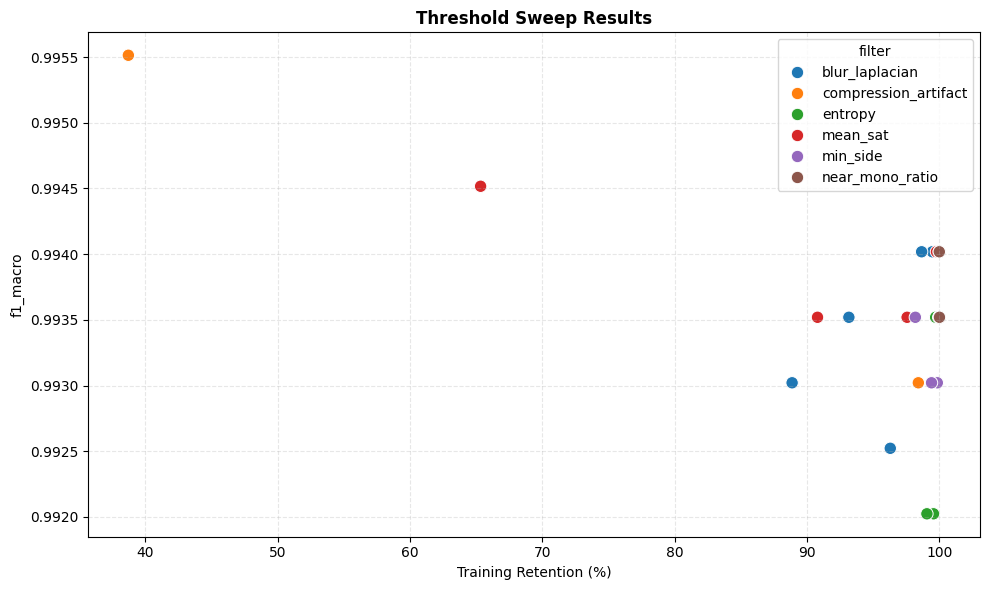

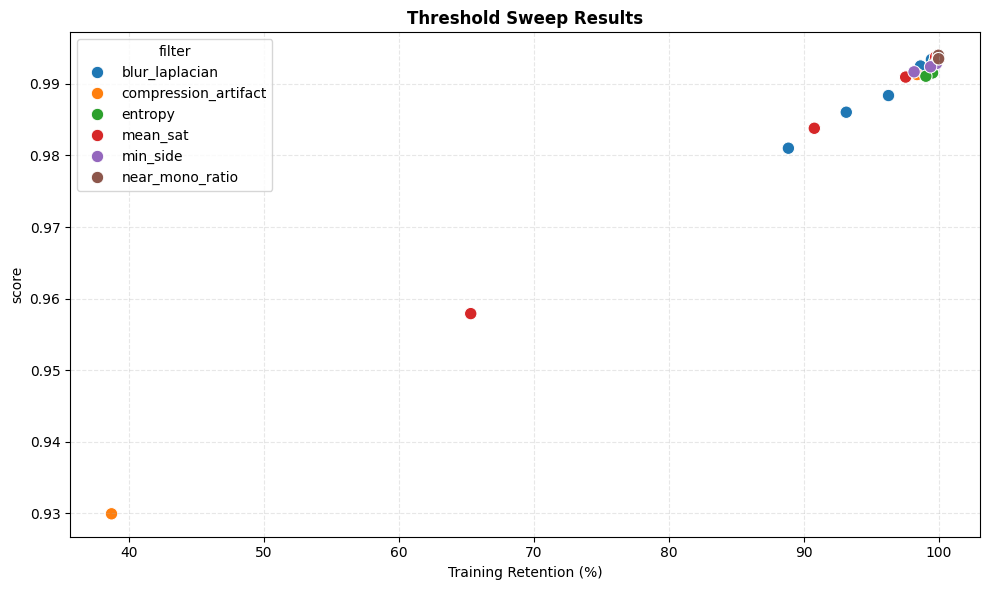

(<Figure size 1000x600 with 1 Axes>,
 <Axes: title={'center': 'Threshold Sweep Results'}, xlabel='Training Retention (%)', ylabel='score'>)

In [12]:
plot_threshold_sweep_results(
    threshold_sweep_df,
    metric_col="f1_macro",
    save_path=figures_dir / "threshold_sweep_f1_vs_retention.png",
    show=True,
)

plot_threshold_sweep_results(
    threshold_sweep_df,
    metric_col="score",
    save_path=figures_dir / "threshold_sweep_score_vs_retention.png",
    show=True,
)

## 9. Cleaning preset evaluation

This section evaluates named cleaning policies:

- `valid_only_no_dedup`
- `minimal_safety`
- `conservative`
- `balanced`
- `strict`

The completed run showed that `balanced` had a slightly higher single-seed F1, but lower retention and worse balance shift. Therefore, stability across multiple seeds is required before selecting a final policy.

In [13]:
presets = get_default_cleaning_presets()

preset_eval_df = evaluate_cleaning_presets(
    X=X_proxy,
    y=y_proxy,
    audit_df=proxy_audit_df,
    presets=presets,
    train_indices=train_indices,
    val_indices=val_indices,
    proxy_config=proxy_config,
    score_config=score_config,
    seed=config["seed"],
)

preset_eval_df = preset_eval_df.sort_values("score", ascending=False).reset_index(drop=True)
save_dataframe(preset_eval_df, reports_dir / "cleaning_preset_evaluation.csv")

display(preset_eval_df)

,filter,threshold,seed,status,invalid_reason,accuracy,f1_macro,precision_macro,recall_macro,n_train,n_val,train_retention_pct,positive_ratio_after,imbalance_shift,score
0,valid_only_no_dedup,preset,42,ok,,0.993519,0.993519,0.993529,0.993522,8022,2006,100.0000,0.500249,0.000000,0.993519
1,minimal_safety,preset,42,ok,,0.993519,0.993519,0.993529,0.993522,8022,2006,100.0000,0.500249,0.000000,0.993519
2,conservative,preset,42,ok,,0.993519,0.993519,0.993522,0.993521,7929,2006,98.8407,0.502081,0.001832,0.992269
3,balanced,preset,42,ok,,0.994516,0.994516,0.994516,0.994517,7576,2006,94.4403,0.511220,0.010970,0.988408
4,strict,preset,42,ok,,0.993519,0.993519,0.993522,0.993521,6820,2006,85.0162,0.518915,0.018666,0.977602


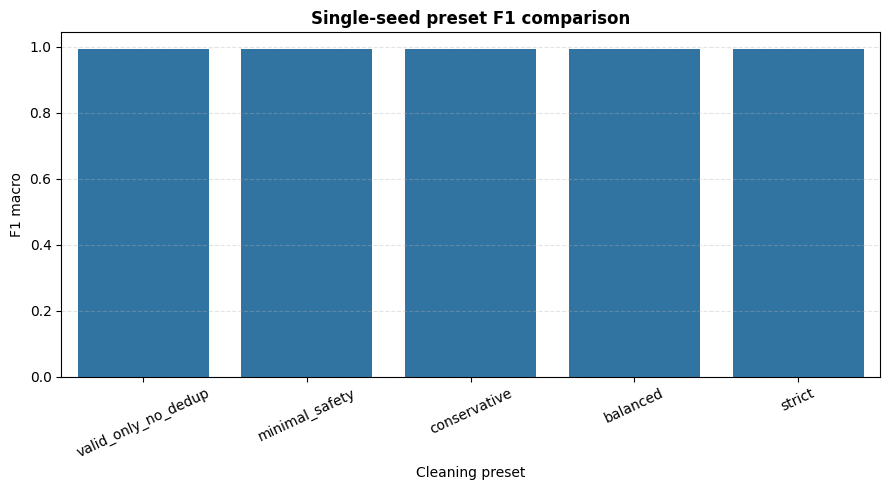

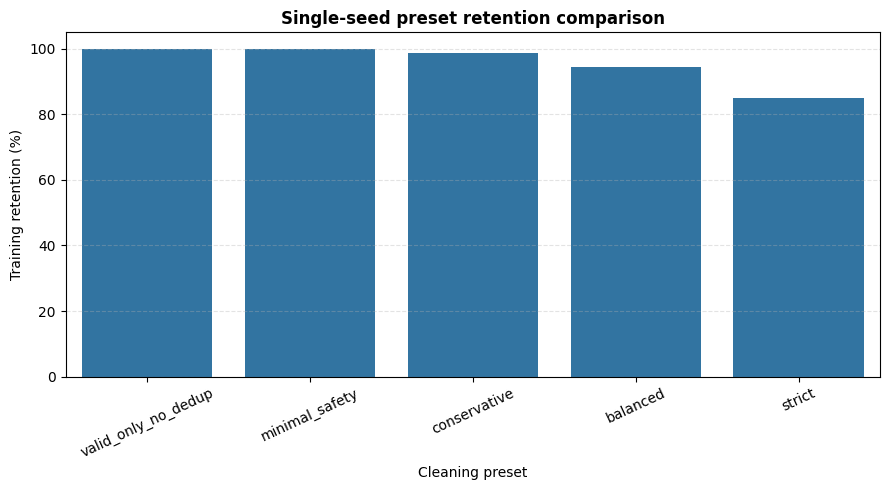

In [14]:
fig, ax = plt.subplots(figsize=(9, 5))
plot_df = preset_eval_df.copy()
sns.barplot(data=plot_df, x="filter", y="f1_macro", ax=ax)
ax.set_title("Single-seed preset F1 comparison", fontweight="bold")
ax.set_xlabel("Cleaning preset")
ax.set_ylabel("F1 macro")
ax.tick_params(axis="x", rotation=25)
ax.grid(axis="y", linestyle="--", alpha=0.35)
fig.tight_layout()
fig.savefig(figures_dir / "preset_single_seed_f1.png", dpi=160, bbox_inches="tight")
plt.show()

fig, ax = plt.subplots(figsize=(9, 5))
sns.barplot(data=plot_df, x="filter", y="train_retention_pct", ax=ax)
ax.set_title("Single-seed preset retention comparison", fontweight="bold")
ax.set_xlabel("Cleaning preset")
ax.set_ylabel("Training retention (%)")
ax.tick_params(axis="x", rotation=25)
ax.grid(axis="y", linestyle="--", alpha=0.35)
fig.tight_layout()
fig.savefig(figures_dir / "preset_single_seed_retention.png", dpi=160, bbox_inches="tight")
plt.show()

## 10. Stability check across seeds

A threshold policy should not be selected from a single random split. This section repeats the proxy-validation protocol across multiple seeds and summarizes mean F1, F1 variance, retention, balance shift, score, and success rate.

Expected stability summary from the completed run:

| Preset | Mean F1 | Mean retention | Mean imbalance shift | Mean score |
|---|---:|---:|---:|---:|
| `minimal_safety` | `0.992821` | `100.00%` | `0.000000` | `0.992821` |
| `balanced` | `0.993220` | `94.91%` | `0.010482` | `0.987608` |
| `strict` | `0.992722` | `85.35%` | `0.019396` | `0.977100` |

Although `balanced` had a slightly higher mean F1, the improvement was below the practical threshold and came with lower retention. The final rule therefore selected the default safety policy.

In [15]:
stability_df, stability_summary_df = run_cleaning_stability_check(
    X=X_proxy,
    y=y_proxy,
    audit_df=proxy_audit_df,
    presets=presets,
    seeds=sweet_cfg["seeds"],
    val_size=sweet_cfg["val_size"],
    proxy_config=proxy_config,
    score_config=score_config,
)

stability_summary_df = stability_summary_df.sort_values("mean_score", ascending=False).reset_index(drop=True)

save_dataframe(stability_df, reports_dir / "cleaning_stability_records.csv")
save_dataframe(stability_summary_df, reports_dir / "cleaning_stability_summary.csv")

display(stability_summary_df)

,filter,mean_f1,std_f1,mean_delta_f1,std_delta_f1,mean_train_retention_pct,mean_imbalance_shift,mean_score,success_rate
0,minimal_safety,0.992821,0.000834,0.000000e+00,0.000000e+00,100.00000,0.000000,0.992821,1.0
1,valid_only_no_dedup,0.992821,0.000834,0.000000e+00,0.000000e+00,100.00000,0.000000,0.992821,1.0
2,conservative,0.992821,0.000834,2.576746e-09,5.761779e-09,98.98528,0.001602,0.991727,1.0
3,balanced,0.993220,0.001148,3.987929e-04,5.460962e-04,94.58240,0.010176,0.987294,1.0
4,strict,0.992722,0.001818,-9.971856e-05,1.241336e-03,85.06608,0.019241,0.976826,1.0


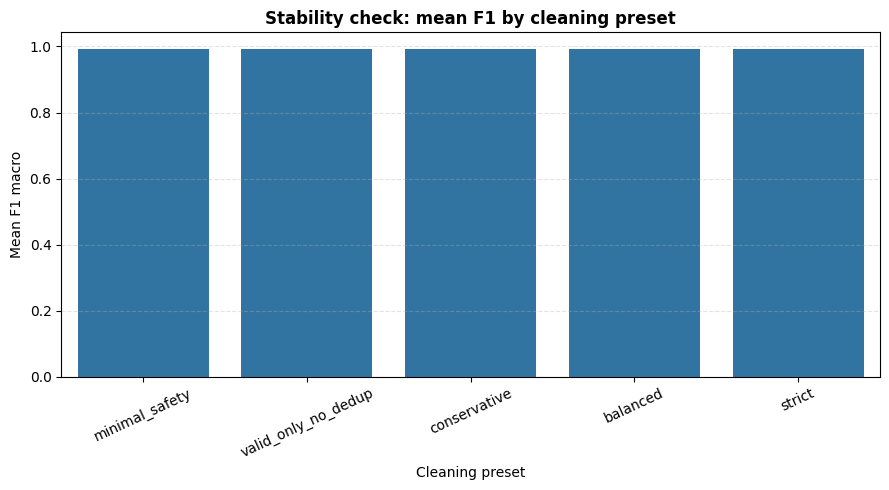

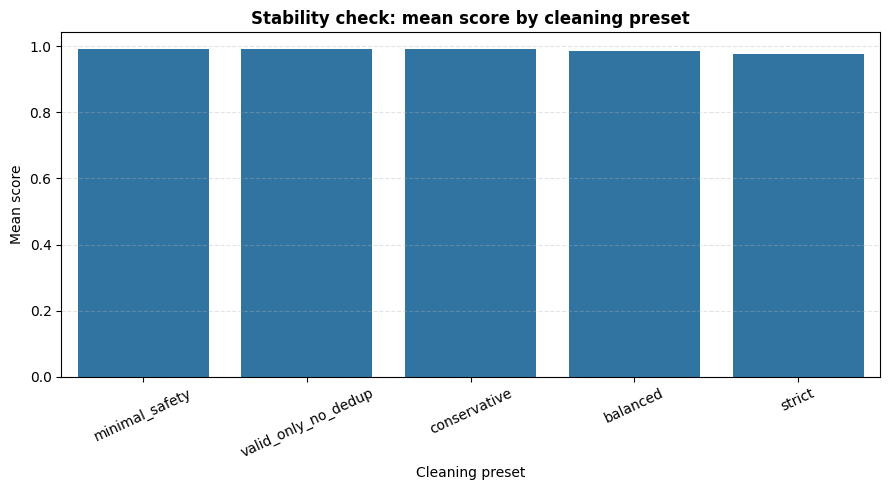

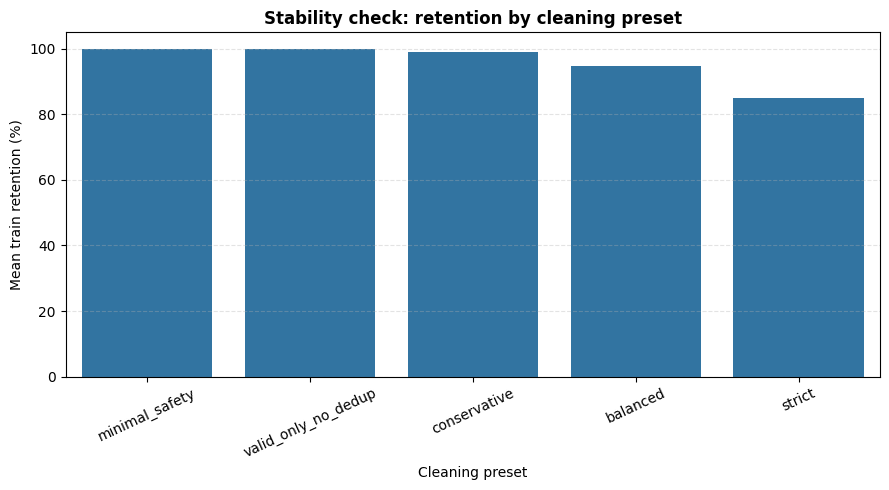

In [16]:
fig, ax = plt.subplots(figsize=(9, 5))
sns.barplot(data=stability_summary_df, x="filter", y="mean_f1", ax=ax)
ax.set_title("Stability check: mean F1 by cleaning preset", fontweight="bold")
ax.set_xlabel("Cleaning preset")
ax.set_ylabel("Mean F1 macro")
ax.tick_params(axis="x", rotation=25)
ax.grid(axis="y", linestyle="--", alpha=0.35)
fig.tight_layout()
fig.savefig(figures_dir / "stability_mean_f1.png", dpi=160, bbox_inches="tight")
plt.show()

fig, ax = plt.subplots(figsize=(9, 5))
sns.barplot(data=stability_summary_df, x="filter", y="mean_score", ax=ax)
ax.set_title("Stability check: mean score by cleaning preset", fontweight="bold")
ax.set_xlabel("Cleaning preset")
ax.set_ylabel("Mean score")
ax.tick_params(axis="x", rotation=25)
ax.grid(axis="y", linestyle="--", alpha=0.35)
fig.tight_layout()
fig.savefig(figures_dir / "stability_mean_score.png", dpi=160, bbox_inches="tight")
plt.show()

fig, ax = plt.subplots(figsize=(9, 5))
sns.barplot(data=stability_summary_df, x="filter", y="mean_train_retention_pct", ax=ax)
ax.set_title("Stability check: retention by cleaning preset", fontweight="bold")
ax.set_xlabel("Cleaning preset")
ax.set_ylabel("Mean train retention (%)")
ax.tick_params(axis="x", rotation=25)
ax.grid(axis="y", linestyle="--", alpha=0.35)
fig.tight_layout()
fig.savefig(figures_dir / "stability_retention.png", dpi=160, bbox_inches="tight")
plt.show()

## 11. Select the final Sweet Spot policy

The selection criteria are:

- `mean_delta_f1 >= 0.001`
- `mean_train_retention_pct >= 85.0`
- `mean_imbalance_shift <= 0.03`

If no preset meets all criteria, select the default policy: `minimal_safety`.

In [17]:
selected_preset, selected_config, selected_row, selection_rule = select_cleaning_policy(
    stability_summary=stability_summary_df,
    presets=presets,
    min_delta_f1=sweet_cfg["min_delta_f1"],
    min_retention_pct=sweet_cfg["min_retention_pct"],
    max_imbalance_shift=sweet_cfg["max_imbalance_shift"],
    default_policy=sweet_cfg["default_policy"],
)

print("Selected preset:", selected_preset)
print("Selection rule:", selection_rule)
print("Selected config:")
print(json.dumps(selected_config, indent=2))

display(pd.DataFrame([selected_row.to_dict()]))

Selected preset: minimal_safety
Selection rule: No preset met all predefined criteria, so the default policy was selected.
Selected config:
{
  "enabled": false,
  "remove_corrupted": true,
  "remove_duplicates": true
}


,filter,mean_f1,std_f1,mean_delta_f1,std_delta_f1,mean_train_retention_pct,mean_imbalance_shift,mean_score,success_rate,meets_practical_gain,meets_retention,meets_balance
0,minimal_safety,0.992821,0.000834,0.0,0.0,100.0,0.0,0.992821,1.0,False,True,True


## 12. Apply the selected cleaning policy

The final selected policy is:

```python
{
    "enabled": False,
    "remove_corrupted": True,
    "remove_duplicates": True,
    "duplicate_hamming_threshold": 4,
}
```

In the completed run, this policy removed `0` images and retained all `10,028` images.

In [18]:
final_clean_df, removed_df = apply_cleaning(audit_df, selected_config)

cleaning_summary_df = summarize_cleaning(
    raw_df=audit_df,
    clean_df=final_clean_df,
    removed_df=removed_df,
    label_col="label_name",
)

removal_reasons_df = summarize_removal_reasons(
    removed_df,
    reason_col="removal_reasons" if "removal_reasons" in removed_df.columns else "removal_reason",
)

retention_report = evaluate_cleaning_retention(
    raw_df=audit_df,
    clean_df=final_clean_df,
    label_col="label",
)

final_report = build_cleaning_report_payload(
    selected_preset=selected_preset,
    selected_config=selected_config,
    selected_row=selected_row,
    selection_rule=selection_rule,
    audit_df=audit_df,
    final_clean_df=final_clean_df,
    removed_df=removed_df,
    config=config,
)

final_report["retention_report"] = retention_report

save_dataframe(final_clean_df, reports_dir / "final_clean_dataframe.csv")
save_dataframe(removed_df, reports_dir / "removed_dataframe.csv")
save_dataframe(cleaning_summary_df, reports_dir / "cleaning_summary.csv")
save_dataframe(removal_reasons_df, reports_dir / "removal_reasons_summary.csv")
save_json(final_report, reports_dir / "sweet_spot_final_report.json")

display(cleaning_summary_df)
display(removal_reasons_df)
display(pd.DataFrame([retention_report]))

,label_name,count_before,count_after,count_removed,pct_before,pct_after,removal_rate_pct
0,cat,5011,5011,0,49.97,49.97,0.0
1,dog,5017,5017,0,50.03,50.03,0.0
2,TOTAL,10028,10028,0,100.00,100.00,0.0


,removal_reason,count,percentage


,n_before,n_after,n_removed,retention_rate,removal_rate,retention_pct,removal_pct,class_balance_shift,class_balance_shift_pct
0,10028,10028,0,1.0,0.0,100.0,0.0,0.0,0.0


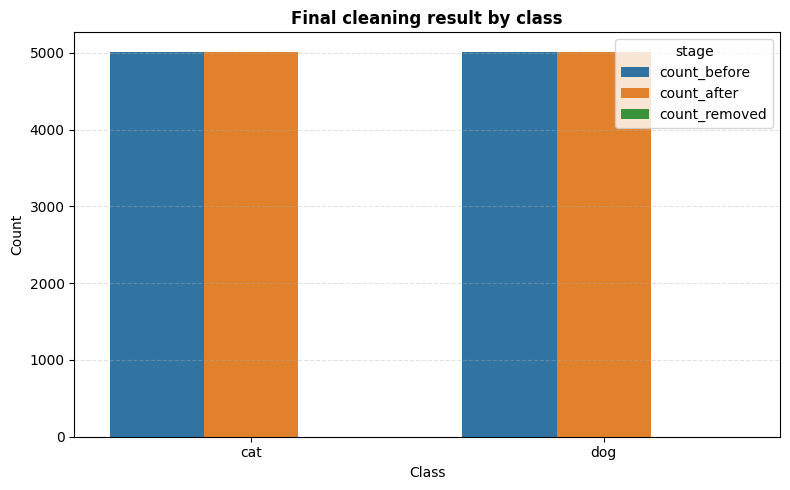

In [19]:
fig, ax = plt.subplots(figsize=(8, 5))
summary_plot_df = cleaning_summary_df[cleaning_summary_df["label_name"].astype(str) != "TOTAL"].copy()
summary_plot_df = summary_plot_df.melt(
    id_vars="label_name",
    value_vars=["count_before", "count_after", "count_removed"],
    var_name="stage",
    value_name="count",
)

sns.barplot(data=summary_plot_df, x="label_name", y="count", hue="stage", ax=ax)
ax.set_title("Final cleaning result by class", fontweight="bold")
ax.set_xlabel("Class")
ax.set_ylabel("Count")
ax.grid(axis="y", linestyle="--", alpha=0.35)
fig.tight_layout()
fig.savefig(figures_dir / "final_cleaning_summary.png", dpi=160, bbox_inches="tight")
plt.show()

In [20]:
if not removed_df.empty:
    plot_image_grid_from_df(
        removed_df,
        n=12,
        path_col="path",
        title_col="label_name" if "label_name" in removed_df.columns else None,
        subtitle_cols=[
            col for col in ["removal_reason", "removal_reasons", "blur_laplacian", "min_side", "entropy"]
            if col in removed_df.columns
        ],
        random_sample=True,
        seed=config["seed"],
        suptitle="Removed Image Examples",
        save_path=figures_dir / "removed_image_examples.png",
        show=True,
    )
else:
    print("No images were removed by the selected policy.")

No images were removed by the selected policy.


## 13. Export final Sweet Spot configuration

This section exports a compact JSON file containing the final cleaning config.

You can use this config in later notebooks or place it directly into `get_default_config()`:

```python
"cleaning": {
    "enabled": False,
    "remove_corrupted": True,
    "remove_duplicates": True,
    "duplicate_hamming_threshold": 4,
}
```

In [21]:
final_cleaning_config = {
    "enabled": bool(selected_config.get("enabled", False)),
    "remove_corrupted": bool(selected_config.get("remove_corrupted", True)),
    "remove_duplicates": bool(selected_config.get("remove_duplicates", True)),
    "duplicate_hamming_threshold": int(selected_config.get("duplicate_hamming_threshold", 4)),
}

top_thresholds_df = (
    threshold_sweep_df
    .sort_values("score", ascending=False)
    .groupby("filter", as_index=False)
    .head(3)
    .reset_index(drop=True)
)

summary_payload = {
    "selected_preset": selected_preset,
    "selection_rule": selection_rule,
    "selected_config": final_cleaning_config,
    "baseline": baseline_result,
    "selected_row": selected_row.to_dict(),
    "retention_report": retention_report,
    "n_raw": int(len(audit_df)),
    "n_clean": int(len(final_clean_df)),
    "n_removed": int(len(removed_df)),
    "outputs": {
        "reports_dir": str(reports_dir),
        "figures_dir": str(figures_dir),
        "features_dir": str(features_dir),
    },
}

save_dataframe(top_thresholds_df, reports_dir / "top_threshold_candidates.csv")
save_json(final_cleaning_config, reports_dir / "final_cleaning_config.json")
save_json(summary_payload, reports_dir / "sweet_spot_summary.json")

print("Final cleaning config:")
print(json.dumps(final_cleaning_config, indent=2))

print("\nSaved outputs:")
print("-", reports_dir / "final_cleaning_config.json")
print("-", reports_dir / "sweet_spot_summary.json")
print("-", reports_dir / "sweet_spot_final_report.json")

display(pd.DataFrame([summary_payload["retention_report"]]))

Final cleaning config:
{
  "enabled": false,
  "remove_corrupted": true,
  "remove_duplicates": true,
  "duplicate_hamming_threshold": 4
}

Saved outputs:
- /content/cat-dog-image-classifier/reports/results/sweet_spot/final_cleaning_config.json
- /content/cat-dog-image-classifier/reports/results/sweet_spot/sweet_spot_summary.json
- /content/cat-dog-image-classifier/reports/results/sweet_spot/sweet_spot_final_report.json


,n_before,n_after,n_removed,retention_rate,removal_rate,retention_pct,removal_pct,class_balance_shift,class_balance_shift_pct
0,10028,10028,0,1.0,0.0,100.0,0.0,0.0,0.0


## 14. Final conclusion

The Sweet Spot experiment selected `minimal_safety` as the final policy.

The tested soft-threshold presets did not provide a practical and stable F1 improvement compared with the valid-only baseline. The final decision is therefore to preserve all usable images and avoid unnecessary data removal.

Final cleaning block for `get_default_config()`:

```python
"cleaning": {
    "enabled": False,
    "remove_corrupted": True,
    "remove_duplicates": True,
    "duplicate_hamming_threshold": 4,
}
```

This result should be used as the default cleaning policy in the Classical Pipeline and Grid Search notebooks.